# Training EfficientNet-B0/B2 — Klasifikasi Kanker Paru-Paru (Citra CT)

Notebook ini mendokumentasikan hasil training model klasifikasi biner `cancer` vs `no_cancer`. Training aktual dijalankan lewat `python src/train.py` (bukan langsung di sel notebook) supaya progres tiap epoch bisa dipantau live saat berjalan; kode training lengkap (transfer learning 2 fase, augmentasi, regularisasi, class weighting, LR scheduling, early stopping) ada di [`src/train.py`](../src/train.py), memakai modul [`src/dataset.py`](../src/dataset.py), [`src/model.py`](../src/model.py), dan [`src/engine.py`](../src/engine.py).

> **Catatan modalitas:** dataset sumber diberi nama "MRI" oleh uploader Kaggle, tapi terkonfirmasi lewat inspeksi visual (lihat `01_eda.ipynb` Bagian 0) sebagai citra **CT scan**. Seluruh dokumentasi di bawah memakai istilah "CT" yang sudah dikoreksi.

## Perjalanan eksperimen

Proses ini melalui **5 iterasi** sebelum mendapat konfigurasi final:

1. **v1-v3** dicoba di atas dataset original (regularisasi berat, regularisasi ringan, backbone lebih besar/EfficientNet-B2) — semuanya mentok di akurasi ~77-79% dan ROC-AUC ~0.84-0.86 berapa pun konfigurasinya diubah.
2. Investigasi lebih lanjut lewat **perceptual hashing** menemukan masalah kualitas data yang serius (ditemukan saat debugging plateau performa, sesudah `01_eda.ipynb` versi awal): dari 3.680 citra, hanya 2.886 yang benar-benar unik, dan **346 grup duplikat bocor lintas split train/val/test** (data leakage), plus **11 grup citra identik dengan label yang saling bertentangan** (label noise).
3. `02_stratified_split.ipynb` diperbarui untuk deduplikasi + membuang label bertentangan sebelum split ulang, menyisakan 2.875 citra bersih.
4. **v4-v5** dilatih ulang di data yang sudah bersih — akurasi turun jadi ~69-70% dan ROC-AUC ~0.77, tapi angka ini **jauh lebih jujur** karena tidak ada leakage.
5. **v5 (EfficientNet-B0, regularisasi diperkuat)** dipilih sebagai model final: performa setara v4 tapi overfitting gap lebih kecil (16.0% vs 20.4%) dengan model yang lebih ringan (4M vs 7.7M parameter).


## 1. Konfigurasi model final (v5)

In [1]:
import json
from pathlib import Path
from IPython.display import Image, display
import pandas as pd

REPORTS_DIR = Path("../reports")

summary = json.loads((REPORTS_DIR / "training_summary.json").read_text())
summary


{'class_names': ['cancer', 'no_cancer'],
 'random_seed': 42,
 'config': {'model_name': 'efficientnet_b0',
  'img_size': 224,
  'batch_size': 32,
  'drop_rate': 0.35,
  'drop_path_rate': 0.25,
  'label_smoothing': 0.1,
  'weight_decay': 0.00015,
  'cancer_recall_boost': 1.3,
  'class_weights': [1.5513641834259033, 0.8605645895004272],
  'phase1_epochs_planned': 8,
  'phase2_epochs_planned': 18,
  'warmup_epochs': 3},
 'epochs_actually_run': 26,
 'best_val_loss': 0.6858769190560361,
 'test_loss': 0.7210236854023404,
 'test_acc': 0.6898148148148148,
 'cancer_recall': 0.6574585635359116,
 'train_test_gap': 0.16008578160665643,
 'best_model_path': 'D:\\skripsi\\models\\best_model.pth'}

## 2. Kurva training

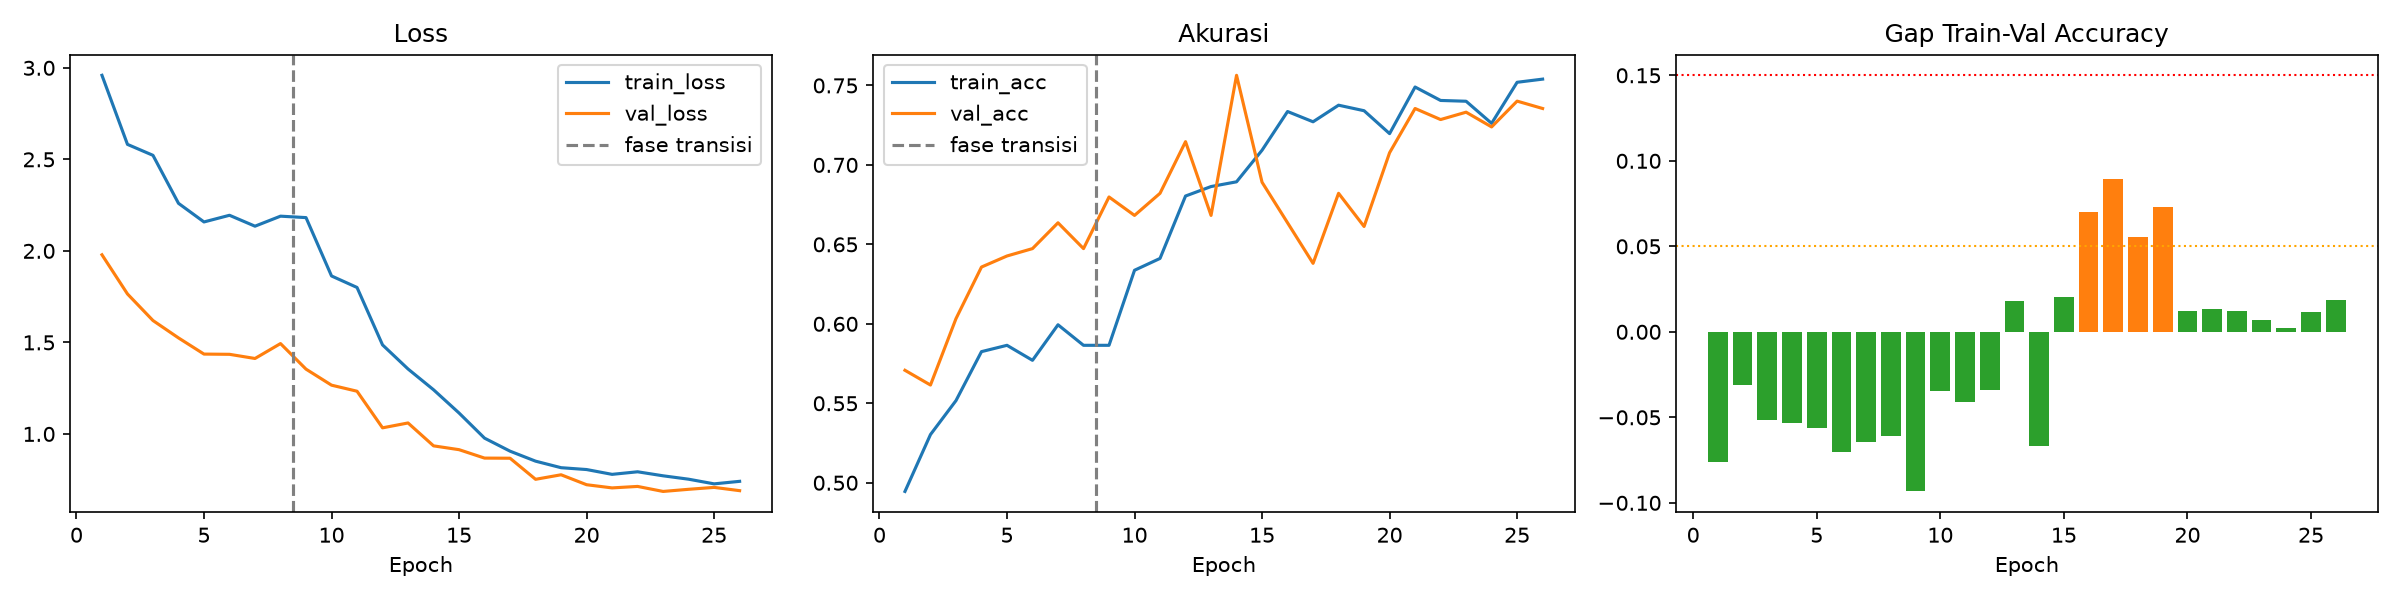

In [2]:
display(Image(filename=str(REPORTS_DIR / "training_curves.png")))


Gap train-val tetap di zona OK/WARNING (tidak pernah masuk OVERFITTING >15% per-epoch) sepanjang training, meski gap final train-vs-**test** sedikit lebih tinggi (16.0%) karena test set adalah data yang benar-benar belum pernah dilihat model.

## 3. Evaluasi test set

In [3]:
report_text = (REPORTS_DIR / "test_classification_report.txt").read_text()
print(report_text)


              precision    recall  f1-score   support

      cancer     0.6230    0.6575    0.6398       181
   no_cancer     0.7427    0.7131    0.7276       251

    accuracy                         0.6898       432
   macro avg     0.6829    0.6853    0.6837       432
weighted avg     0.6926    0.6898    0.6908       432



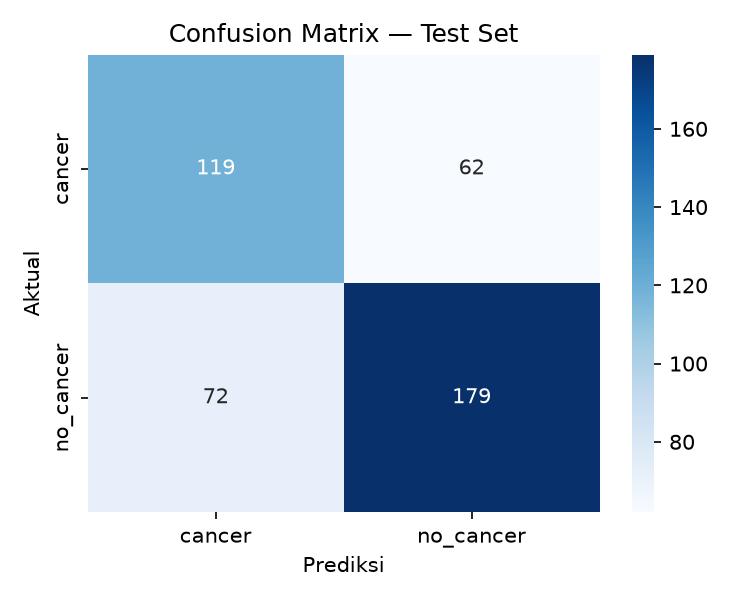

In [4]:
display(Image(filename=str(REPORTS_DIR / "confusion_matrix.png")))


**Catatan klinis:** recall kelas `cancer` (65.7%) masih di bawah target ideal 90% — berarti sekitar 1 dari 3 kasus cancer di test set salah diklasifikasikan sebagai no_cancer. Ini limitasi penting yang harus didiskusikan di Bab V (bukan angka yang sebaiknya disembunyikan).

## 4. Ablation study — perbandingan 5 konfigurasi

In [5]:
ablation = pd.DataFrame(json.loads((REPORTS_DIR / "ablation_comparison.json").read_text()))
ablation = ablation[["version", "data_condition", "model", "test_acc", "cancer_recall", "roc_auc", "train_test_gap", "notes"]]
ablation["test_acc"] = (ablation["test_acc"] * 100).round(1)
ablation["cancer_recall"] = (ablation["cancer_recall"] * 100).round(1)
ablation["train_test_gap"] = (ablation["train_test_gap"] * 100).round(1)
ablation


,version,data_condition,model,test_acc,cancer_recall,roc_auc,train_test_gap,notes
0,v1 - B0 heavy regularization,"leaked (original, with duplicates)",efficientnet_b0,78.6,66.5,0.859,10.0,"Dropout 0.3, drop_path 0.2, label_smoothing 0...."
1,v2 - B0 light regularization,"leaked (original, with duplicates)",efficientnet_b0,77.0,70.8,0.843,11.7,"Dropout 0.15, drop_path 0.1, label_smoothing 0..."
2,v3 - B2 256px,"leaked (original, with duplicates)",efficientnet_b2 (256px),78.6,69.4,0.860,14.6,"Dropout 0.2, drop_path 0.15, label_smoothing 0..."
3,v4 - B2 256px (clean data),deduplicated (leakage + conflicting labels rem...,efficientnet_b2 (256px),69.9,67.4,0.772,20.4,Sama seperti v3 tapi di data bersih -> overfit...
4,v5 - B0 clean (FINAL),deduplicated (leakage + conflicting labels rem...,efficientnet_b0 (224px),69.0,65.7,0.773,16.0,"Model final. Dropout 0.35, drop_path 0.25, wei..."


**Insight utama dari ablation ini:** mengubah regularisasi (v1 vs v2) atau memperbesar backbone (v1/v2 vs v3) di dataset yang sama (leaked) hanya menggeser trade-off precision-recall — tidak mendorong performa ke atas. Begitu dataset dibersihkan (v3 vs v4), ROC-AUC turun tajam dari ~0.86 ke ~0.77, membuktikan performa v1-v3 sebagian besar adalah artefak data leakage, bukan kemampuan model yang sesungguhnya. Ini alasan kenapa deduplikasi data harus dilakukan **sebelum** tuning hyperparameter, bukan sesudah.


## 5. Temuan kualitas data (untuk Bab III/IV — metodologi)

In [6]:
dedup_manifest = pd.read_csv(REPORTS_DIR / "dataset_deduplicated_manifest.csv")
original_total = 3680
print(f"Total citra asli: {original_total}")
print(f"Total citra unik setelah dedup + drop conflicting label: {len(dedup_manifest)}")
print(f"Citra yang dibuang: {original_total - len(dedup_manifest)} "
      f"({(original_total - len(dedup_manifest)) / original_total * 100:.1f}%)")

print("\nDistribusi kelas SEBELUM dedup (raw manifest):")
raw_manifest = pd.read_csv(REPORTS_DIR / "dataset_manifest.csv")
print((raw_manifest["label"].value_counts(normalize=True) * 100).round(1))

print("\nDistribusi kelas SETELAH dedup:")
print((dedup_manifest["label"].value_counts(normalize=True) * 100).round(1))


Total citra asli: 3680
Total citra unik setelah dedup + drop conflicting label: 2875
Citra yang dibuang: 805 (21.9%)

Distribusi kelas SEBELUM dedup (raw manifest):
label
cancer       50.9
no_cancer    49.1
Name: proportion, dtype: float64

Distribusi kelas SETELAH dedup:
label
no_cancer    58.1
cancer       41.9
Name: proportion, dtype: float64


Rasio kelas bergeser dari ~51:49 (cancer:no_cancer) menjadi ~42:58 setelah dedup. Artinya kelas `cancer` di dataset mentah proporsinya lebih banyak diduplikasi — dataset asli **terlihat** seimbang, padahal setelah dibersihkan sebenarnya timpang ke arah `no_cancer`. Ini contoh konkret kenapa cek kualitas data (duplikasi, label noise) harus jadi bagian standar EDA untuk dataset yang dikumpulkan/di-scrape, bukan cuma hitung jumlah file per kelas.


## 6. Kesimpulan & limitasi

- Model final (EfficientNet-B0, data bersih): **akurasi test 69.0%, ROC-AUC 0.773, recall cancer 65.7%**.
- Angka ini jauh lebih rendah dari target awal (90%+) yang ditetapkan di awal penelitian, tapi **jauh lebih dapat dipercaya** karena tidak ada data leakage.
- Ceiling ~0.77 AUC konsisten di 2 arsitektur berbeda (B0 dan B2) dengan berbagai regularisasi — mengindikasikan keterbatasan ini kemungkinan besar berasal dari kualitas dan ukuran dataset (2.875 citra unik, distribusi ukuran citra yang tidak seragam 168-1200px, label yang sebagian ambigu) daripada dari pilihan arsitektur/hyperparameter.
- **Koreksi modalitas citra (MRI → CT)**: dataset yang diklaim "MRI" oleh uploader Kaggle terbukti secara visual adalah citra CT scan (lihat `01_eda.ipynb` Bagian 0). Ini bukan sekadar detail teknis — memengaruhi judul dan kerangka teori skripsi secara langsung, dan penting didiskusikan di Bab III (metodologi) sebagai bagian dari proses verifikasi data.
- Rekomendasi untuk penelitian lanjutan: kumpulkan data tambahan dari sumber lain (idealnya dataset CT paru yang sudah terverifikasi, karena dataset MRI paru publik sangat jarang tersedia), libatkan radiolog untuk relabeling kasus ambigu, atau gunakan cross-validation untuk mengestimasi variansi performa dengan lebih baik.
